### Lab Prediction from Plasmid Sequences using CNN

#### 1. Function of this notebook
This notebook demonstrates how to predict depositing lab labels from plasmid DNA sequences using a CNN model.
The CNN takes one-hot encoded DNA sequences (up to 16kb) as input and predicts the lab label.
It uses cluster-based 5-fold cross-validation to ensure sequences from the same cluster stay together 
(preventing data leakage from similar sequences).

#### 2. Input and Output
**Input files (in the same folder):**
- addgene_subsampled.fasta: Plasmid sequences in FASTA format
- addgene_lab_subsampled.txt: Lab indices for each plasmid
- clusters_subsampled.tsv: Pre-computed sequence clustering results (95% identity)
- Please note that we subsampled 5k Addgene sequences to speed up calculation

**Output:**
- A combined plot showing AUROC, Top-1, Top-5, and Top-10 accuracy across 5 folds

#### 3. Time estimation
- Data loading and encoding: ~2 minutes
- Training (1 seed × 5 folds × 20 epochs): ~2-10 min (depending on GPU)
- Total runtime: ~ 5-20 min

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import heapq
from Bio import SeqIO

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.metrics import roc_auc_score

In [5]:
FASTA_FILE = "addgene_subsampled.fasta"
LAB_FILE = "addgene_lab_subsampled.txt"
CLU_FILE = "clusters_subsampled.tsv"

In [6]:
# DNA sequence encoding
base_mapping = {'A': 0, 'T': 1, 'C': 2, 'G': 3, 'N': 4}

def one_hot_encode_sequence(sequence, max_len=16000):
    """One-hot encode a DNA sequence with padding/truncation to max_len."""
    encoded_sequence = np.ones(max_len, dtype=np.int32) * 4  # Initialize with N (4)
    
    if len(sequence) > max_len:
        sequence = sequence[:max_len]
    
    for i, base in enumerate(sequence):
        if i >= max_len:
            break
        encoded_sequence[i] = base_mapping.get(base, 4)
    
    return encoded_sequence

def one_hot_encode_batch(batch, num_classes=5):
    """Convert batch of encoded sequences to one-hot format."""
    batch = batch.long()
    return F.one_hot(batch, num_classes).permute(0, 2, 1).float()

In [7]:
# CNN Model
class CNNModel(nn.Module):
    def __init__(self, input_length, filter_num=128, filter_len=12, num_dense_nodes=64, num_classes=10):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=5, out_channels=filter_num, kernel_size=filter_len, padding="same")
        self.pool = nn.MaxPool1d(kernel_size=input_length)
        self.batchnorm1 = nn.BatchNorm1d(filter_num)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(filter_num, num_dense_nodes)
        self.batchnorm2 = nn.BatchNorm1d(num_dense_nodes)
        self.fc2 = nn.Linear(num_dense_nodes, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = self.batchnorm1(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.batchnorm2(x)
        x = self.fc2(x)
        return x

In [8]:
# LPT algorithm for splitting clusters into k folds
def lpt_split_to_folds(cluster_tsv: Path, k: int = 5, seed: int = None):
    """Split samples into k folds using LPT algorithm, keeping clusters together."""
    rep_members = defaultdict(list)
    rep_size = defaultdict(int)
    
    with open(cluster_tsv, "r") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) != 2:
                continue
            rep, mem = parts
            rep_members[rep].append(mem)
            rep_size[rep] += 1

    reps_sizes = list(rep_size.items())
    if seed is None:
        sorted_reps = sorted(reps_sizes, key=lambda x: (-x[1], x[0]))
    else:
        rng = np.random.RandomState(seed)
        size2reps = defaultdict(list)
        for rep, sz in reps_sizes:
            size2reps[sz].append(rep)
        sorted_reps = []
        for sz in sorted(size2reps.keys(), reverse=True):
            reps = size2reps[sz]
            rng.shuffle(reps)
            for rep in reps:
                sorted_reps.append((rep, sz))

    heap = [(0, i) for i in range(k)]
    heapq.heapify(heap)
    fold_reps = {i: [] for i in range(k)}
    
    for rep, sz in sorted_reps:
        load, fid = heapq.heappop(heap)
        fold_reps[fid].append(rep)
        heapq.heappush(heap, (load + sz, fid))

    seq_to_fold = {}
    for fid in range(k):
        for rep in fold_reps[fid]:
            for m in rep_members[rep]:
                seq_to_fold[m] = fid

    fold_counts = [sum(rep_size[r] for r in fold_reps[i]) for i in range(k)]
    
    return seq_to_fold, fold_counts

In [10]:
# Load sequences and labels
print("Loading sequences from FASTA file...")
sequences = []
seq_ids = []
for record in SeqIO.parse(FASTA_FILE, "fasta"):
    seq_ids.append(record.id)
    sequence = str(record.seq).upper()
    encoded_seq = one_hot_encode_sequence(sequence, max_len=16000)
    sequences.append(encoded_seq)

sequences = np.array(sequences)
seq_ids = np.array(seq_ids)
print(f"Loaded {len(sequences)} sequences")

print("Loading labels...")
labels = np.loadtxt(LAB_FILE, dtype=float)
labels = np.rint(labels).astype(int)
print(f"Labels shape: {labels.shape}")

# Ensure same length
assert len(sequences) == len(labels), f"Mismatch: {len(sequences)} sequences vs {len(labels)} labels"


# Filter out samples with label 0 (unknown lab)
valid_mask = labels > 0
sequences = sequences[valid_mask]
labels = labels[valid_mask]
seq_ids = seq_ids[valid_mask]
print(f"After filtering label=0: {len(sequences)} samples")

# Remap labels to contiguous IDs
classes = np.unique(labels)
orig2new = {c: i for i, c in enumerate(classes)}
labels_mapped = np.array([orig2new[v] for v in labels], dtype=int)
num_classes = len(classes)
print(f"Number of classes: {num_classes}")

Loading sequences from FASTA file...
Loaded 5000 sequences
Loading labels...
Labels shape: (5000,)
After filtering label=0: 3369 samples
Number of classes: 772


In [11]:
# Training parameters
INPUT_LENGTH = 16000
EPOCHS = 20
BATCH_SIZE = 64
LR = 1e-3
K_FOLDS = 5
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Custom Dataset class
class SequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return torch.tensor(self.sequences[idx], dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)

# Evaluation function
def eval_model(model, loader, device, num_classes):
    """Evaluate model and return AUROC, Top-1, Top-5, Top-10 accuracy."""
    model.eval()
    all_probs, all_labels = [], []
    
    with torch.no_grad():
        for seqs, labs in loader:
            seqs, labs = seqs.to(device), labs.to(device)
            seqs = one_hot_encode_batch(seqs)
            outputs = model(seqs)
            probs = torch.softmax(outputs, dim=1)
            all_probs.append(probs.cpu())
            all_labels.append(labs.cpu())
    
    if not all_probs:
        return float("nan"), 0.0, 0.0, 0.0
    
    P = torch.cat(all_probs)
    Y = torch.cat(all_labels)
    
    # Macro-averaged AUROC
    P_np, Y_np = P.numpy(), Y.numpy()
    aurocs = []
    for c in range(num_classes):
        pos = (Y_np == c)
        n_pos, n_neg = int(pos.sum()), int((~pos).sum())
        if n_pos >= 5 and n_neg >= 1:
            aurocs.append(roc_auc_score(pos.astype(int), P_np[:, c]))
    auroc = float(np.mean(aurocs)) if aurocs else float("nan")
    
    # Top-1 accuracy
    top1 = (P.argmax(dim=1) == Y).float().mean().item()
    
    # Top-5 accuracy
    k5 = min(5, P.shape[1])
    if k5 >= 2:
        top5 = (P.topk(k5, dim=1).indices == Y[:, None]).any(dim=1).float().mean().item()
    else:
        top5 = top1
    
    # Top-10 accuracy
    k10 = min(10, P.shape[1])
    if k10 >= 2:
        top10 = (P.topk(k10, dim=1).indices == Y[:, None]).any(dim=1).float().mean().item()
    else:
        top10 = top5
    
    return auroc, top1, top5, top10

Device: cuda


In [12]:
# Run cluster-based 5-fold CV
all_results = []

print(f"\n{'='*50}")
print(f"Running 5-fold CV with seed {SEED}")
print(f"{'='*50}")

# Get fold assignments
seq_to_fold, fold_counts = lpt_split_to_folds(Path(CLU_FILE), k=K_FOLDS, seed=SEED)
print(f"Cluster-based fold distribution: {fold_counts}")

# Create fold array based on sequence IDs
fold_arr = np.zeros(len(labels_mapped), dtype=int)
matched = 0

for i, sid in enumerate(seq_ids):
    if sid in seq_to_fold:
        fold_arr[i] = seq_to_fold[sid]
        matched += 1
    else:
        # Try to extract ID from different formats
        for fmt_id in [sid.split('_')[-1], sid.split('|')[0]]:
            if fmt_id in seq_to_fold:
                fold_arr[i] = seq_to_fold[fmt_id]
                matched += 1
                break
        else:
            # Fallback: deterministic assignment
            rng = np.random.RandomState(SEED + i)
            fold_arr[i] = rng.randint(0, K_FOLDS)

print(f"Matched sequences: {matched}/{len(seq_ids)}")
print(f"Fold distribution: {[np.sum(fold_arr == f) for f in range(K_FOLDS)]}")

# Set random seeds
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Create full dataset
full_dataset = SequenceDataset(sequences, labels_mapped)

for fold in range(K_FOLDS):
    print(f"\n--- Fold {fold + 1}/{K_FOLDS} ---")
    
    # Split data
    test_mask = (fold_arr == fold)
    train_mask = ~test_mask
    
    train_indices = np.where(train_mask)[0]
    test_indices = np.where(test_mask)[0]
    
    print(f"Train: {len(train_indices)}, Test: {len(test_indices)}")
    
    if len(test_indices) == 0 or len(train_indices) == 0:
        print("Insufficient samples, skipping...")
        all_results.append({
            'seed': SEED, 'fold': fold,
            'auroc': np.nan, 'top1': np.nan, 'top5': np.nan, 'top10': np.nan
        })
        continue
    
    # Create data loaders
    train_subset = Subset(full_dataset, train_indices)
    test_subset = Subset(full_dataset, test_indices)
    
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)
    
    # Initialize model
    model = CNNModel(input_length=INPUT_LENGTH, num_classes=num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    
    # Training loop
    best_auroc = -1.0
    best_metrics = (np.nan, 0.0, 0.0, 0.0)
    
    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0.0
        
        for seqs, labs in train_loader:
            seqs, labs = seqs.to(device), labs.to(device)
            seqs = one_hot_encode_batch(seqs)
            
            optimizer.zero_grad()
            outputs = model(seqs)
            loss = criterion(outputs, labs)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        # Evaluate
        auroc, top1, top5, top10 = eval_model(model, test_loader, device, num_classes)
        
        if auroc == auroc and auroc > best_auroc:
            best_auroc = auroc
            best_metrics = (auroc, top1, top5, top10)
        
        print(f"Epoch {epoch}: Loss={total_loss/len(train_loader):.4f}, "
              f"AUROC={auroc:.4f}, Top1={top1:.4f}, Top5={top5:.4f}, Top10={top10:.4f}")
    
    auroc, top1, top5, top10 = best_metrics
    print(f"Best: AUROC={auroc:.4f}, Top1={top1:.4f}, Top5={top5:.4f}, Top10={top10:.4f}")
    
    all_results.append({
        'seed': SEED, 'fold': fold,
        'auroc': auroc, 'top1': top1, 'top5': top5, 'top10': top10
    })


Running 5-fold CV with seed 42
Cluster-based fold distribution: [674, 674, 674, 674, 673]
Matched sequences: 0/3369
Fold distribution: [692, 659, 703, 629, 686]

--- Fold 1/5 ---
Train: 2677, Test: 692


C:\Users\TriCityPC\.conda\envs\transformers2\lib\site-packages\torch\nn\modules\conv.py:309: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\Convolution.cpp:1004.)
  return F.conv1d(input, weight, bias, self.stride,


Epoch 1: Loss=6.2533, AUROC=0.8901, Top1=0.1590, Top5=0.2081, Top10=0.2413
Epoch 2: Loss=5.3968, AUROC=0.9300, Top1=0.2197, Top5=0.3179, Top10=0.3642
Epoch 3: Loss=4.8250, AUROC=0.9500, Top1=0.2645, Top5=0.3642, Top10=0.4075
Epoch 4: Loss=4.3204, AUROC=0.9508, Top1=0.2977, Top5=0.3829, Top10=0.4393
Epoch 5: Loss=3.8742, AUROC=0.9509, Top1=0.3165, Top5=0.4075, Top10=0.4552
Epoch 6: Loss=3.4709, AUROC=0.9595, Top1=0.3064, Top5=0.4364, Top10=0.4827
Epoch 7: Loss=3.0999, AUROC=0.9588, Top1=0.3237, Top5=0.4566, Top10=0.5072
Epoch 8: Loss=2.7752, AUROC=0.9575, Top1=0.3382, Top5=0.4668, Top10=0.5159
Epoch 9: Loss=2.4543, AUROC=0.9527, Top1=0.3555, Top5=0.4740, Top10=0.5260
Epoch 10: Loss=2.1803, AUROC=0.9506, Top1=0.3642, Top5=0.4884, Top10=0.5332
Epoch 11: Loss=1.9175, AUROC=0.9475, Top1=0.3815, Top5=0.4928, Top10=0.5332
Epoch 12: Loss=1.6856, AUROC=0.9539, Top1=0.3844, Top5=0.5058, Top10=0.5477
Epoch 13: Loss=1.4590, AUROC=0.9450, Top1=0.3873, Top5=0.5087, Top10=0.5564
Epoch 14: Loss=1.2751

In [13]:
# Convert results to DataFrame
df_results = pd.DataFrame(all_results)
print("\nAll Results:")
print(df_results)

# Calculate mean and std
print("\nSummary Statistics:")
for metric in ['auroc', 'top1', 'top5', 'top10']:
    mean_val = df_results[metric].mean()
    std_val = df_results[metric].std()
    print(f"{metric}: {mean_val:.4f} ± {std_val:.4f}")


All Results:
   seed  fold     auroc      top1      top5     top10
0    42     0  0.959477  0.306358  0.436416  0.482659
1    42     1  0.949226  0.385432  0.503794  0.550835
2    42     2  0.954370  0.398293  0.504979  0.547653
3    42     3  0.935734  0.341812  0.454690  0.500795
4    42     4  0.947651  0.377551  0.495627  0.534985

Summary Statistics:
auroc: 0.9493 ± 0.0089
top1: 0.3619 ± 0.0375
top5: 0.4791 ± 0.0315
top10: 0.5234 ± 0.0302


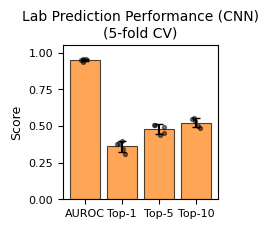

In [15]:
# Plot AUROC, Top-1, Top-5, Top-10 in a single figure
metrics = ['auroc', 'top1', 'top5', 'top10']
metric_labels = ['AUROC', 'Top-1', 'Top-5', 'Top-10']

means = [df_results[m].mean() for m in metrics]
stds = [df_results[m].std(ddof=1) for m in metrics]

x = np.arange(len(metrics))
bar_width = 0.8

plt.figure(figsize=(2, 2))

# Bar plot with error bars
bars = plt.bar(x, means, yerr=stds, width=bar_width, 
               color='C1', alpha=0.7, edgecolor='black', linewidth=0.8, capsize=3)

# Scatter individual data points
jitter = 0.15
for i, m in enumerate(metrics):
    values = df_results[m].values
    jittered_x = np.full(len(values), x[i]) + (np.random.rand(len(values)) - 0.5) * 2 * jitter
    plt.scatter(jittered_x, values, color='black', s=8, alpha=0.5, zorder=5)

plt.xticks(x, metric_labels, fontsize=9)
plt.ylabel('Score', fontsize=9)
plt.ylim(0, 1.05)
plt.title('Lab Prediction Performance (CNN)\n(5-fold CV)', fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)


plt.show()